In [13]:
import pandas as pd
import numpy as np
data=pd.read_csv("house_price_regression_dataset.csv")
print(data.head(10))

   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   
5            3944             5              3        1990  2.475930   
6            3671             1              2        2012  4.911960   
7            3419             1              1        1972  2.805281   
8             630             3              3        1997  1.014286   
9            2185             4              2        1981  3.941604   

   Garage_Size  Neighborhood_Quality   House_Price  
0            0                     5  2.623829e+05  
1            1                     6  9.852609e+05  
2            0                     9  7.779774e+

In [7]:
print(data.shape)

(1000, 8)


In [15]:
import seaborn as sns

In [17]:
print(data.columns)

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')


In [19]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB
None


In [21]:
print(data.describe())

       Square_Footage  Num_Bedrooms  Num_Bathrooms   Year_Built     Lot_Size  \
count     1000.000000   1000.000000    1000.000000  1000.000000  1000.000000   
mean      2815.422000      2.990000       1.973000  1986.550000     2.778087   
std       1255.514921      1.427564       0.820332    20.632916     1.297903   
min        503.000000      1.000000       1.000000  1950.000000     0.506058   
25%       1749.500000      2.000000       1.000000  1969.000000     1.665946   
50%       2862.500000      3.000000       2.000000  1986.000000     2.809740   
75%       3849.500000      4.000000       3.000000  2004.250000     3.923317   
max       4999.000000      5.000000       3.000000  2022.000000     4.989303   

       Garage_Size  Neighborhood_Quality   House_Price  
count  1000.000000           1000.000000  1.000000e+03  
mean      1.022000              5.615000  6.188610e+05  
std       0.814973              2.887059  2.535681e+05  
min       0.000000              1.000000  1.116269e

In [25]:
print(data.isnull().sum())

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


In [33]:
data.duplicated().sum()

0

In [35]:
data.drop_duplicates()


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [43]:
data["House_Price"].describe()

count    1.000000e+03
mean     6.188610e+05
std      2.535681e+05
min      1.116269e+05
25%      4.016482e+05
50%      6.282673e+05
75%      8.271413e+05
max      1.108237e+06
Name: House_Price, dtype: float64

In [45]:
X=data.drop("House_Price",axis=1)
y=data["House_Price"]
X.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,1360,2,1,1981,0.599637,0,5
1,4272,3,3,2016,4.753014,1,6
2,3592,1,2,2016,3.634823,0,9
3,966,1,2,1977,2.730667,1,8
4,4926,2,1,1993,4.699073,0,8


In [47]:
y.head()

0    2.623829e+05
1    9.852609e+05
2    7.779774e+05
3    2.296989e+05
4    1.041741e+06
Name: House_Price, dtype: float64

In [53]:
print("X shape : ",X.shape)
print("y shape : ",y.shape)

X shape :  (1000, 7)
y shape :  (1000,)


In [55]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [63]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(800, 7)
(200, 7)
(800,)
(200,)


In [65]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [75]:
X_train_scaled=pd.DataFrame(
    X_train_scaled,columns=X_train.columns,
    index=X_train.index)
X_test_scaled=pd.DataFrame(
    X_test_scaled,columns=X_test.columns,
    index=X_test.index)

In [81]:
X_train_scaled.head()
print(X_train_scaled.head().describe())

       Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
count        5.000000      5.000000       5.000000    5.000000  5.000000   
mean         0.355675      0.444391       0.525600   -0.129950  0.165725   
std          0.725873      1.067647       1.096468    1.039347  0.951336   
min         -0.627722     -0.681986      -1.190644   -1.005096 -0.929572   
25%          0.045608     -0.681986       0.035244   -0.957011 -0.770120   
50%          0.444973      0.725985       1.261133   -0.620416  0.510449   
75%          0.563185      1.429971       1.261133    0.629793  0.965113   
max          1.352331      1.429971       1.261133    1.302982  1.052757   

       Garage_Size  Neighborhood_Quality  
count     5.000000              5.000000  
mean     -0.262219             -0.136007  
std       1.336033              1.270432  
min      -1.237920             -1.577593  
25%      -1.237920             -1.234358  
50%      -1.237920              0.138581  
75%       1.20

In [79]:
X_test_scaled.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
521,0.956959,0.022000,-1.190644,1.399152,-0.525799,-0.018294,-0.204654
737,-0.402480,0.022000,-1.190644,0.052773,-1.093878,-0.018294,-0.547889
740,1.512876,-1.385972,1.261133,-1.197436,-0.763741,-0.018294,0.825051
660,1.691791,-0.681986,-1.190644,-0.716586,1.331359,-0.018294,-1.234358
411,0.664624,-1.385972,-1.190644,0.341283,0.942529,-1.237920,1.168285


In [93]:
from sklearn.linear_model import LinearRegression
model1=LinearRegression()
X_simple=data[["Square_Footage"]]
y=data["House_Price"]
X_train_simple,X_test_simple,y_train_simple,y_test_simple=train_test_split(
    X_simple,y,test_size=0.2,random_state=42)
model1.fit(X_train_simple,y_train_simple)
y_pred_simple=model1.predict(X_test_simple)
y_pred_simple[:10]

array([ 858863.24859834,  517515.44416559,  998450.83489986,
       1043375.57531874,  785459.43166392,  773426.01905172,
        984411.85351896,  881927.28943839,  812534.61004137,
        905191.88715531])

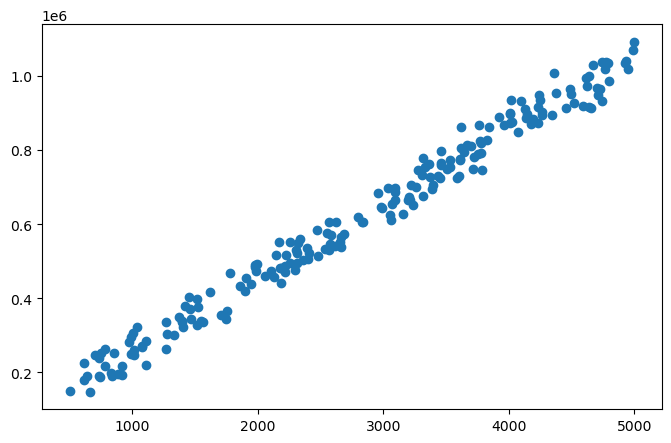

In [101]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(X_test_simple,y_test_simple,label="Actual")


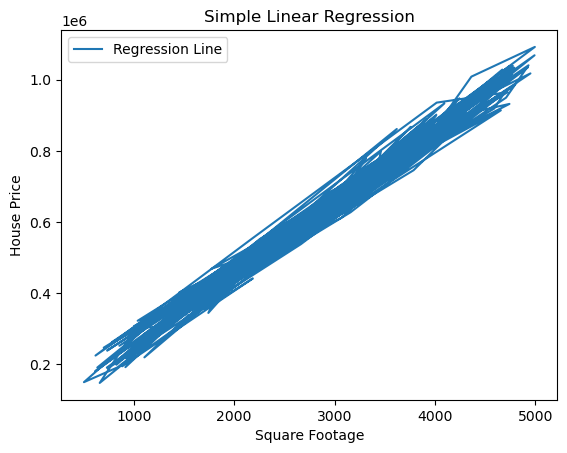

In [111]:
plt.plot(X_test_simple,y_test_simple,label="Regression Line")
plt.legend()
plt.xlabel("Square Footage")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

In [131]:
print("Model Evaluation")
print("-------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation
-------------------------
MAE : 8174.583600006595
MSE : 8174.583600006595
RMSE: 90.41340387357725
R²  : 0.9984263636823413


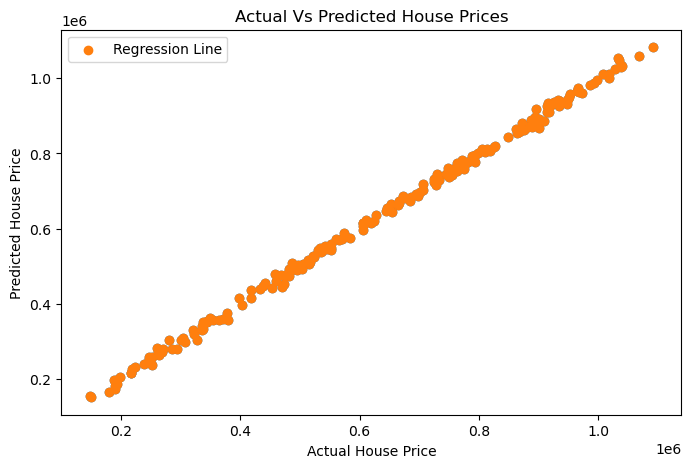

In [145]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred_multiple)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual Vs Predicted House Prices")
plt.scatter(y_test,y_pred_multiple,label="Regression Line")
plt.legend()
plt.show()

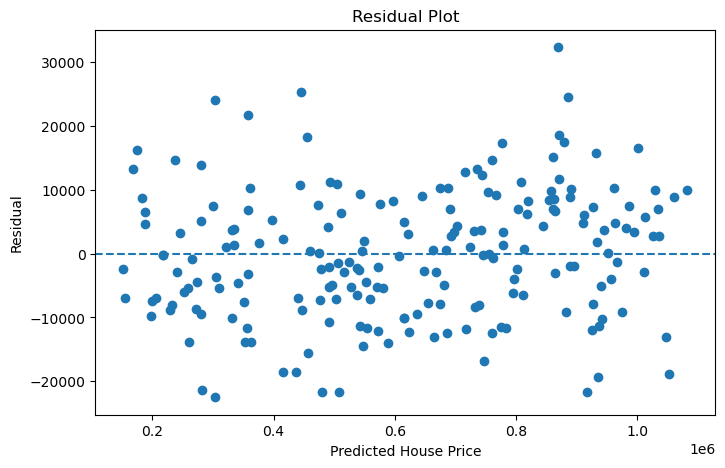

In [149]:
plt.figure(figsize=(8,5))
residuals = y_test - y_pred_multiple
plt.scatter(
    y_pred_multiple,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [151]:
print('''X = Features
y = Target

fit()
↓
Model learns

predict()
↓
Model makes predictions

Actual - Predicted
↓
Residual

MAE
↓
Average absolute error

MSE
↓
Squared error

RMSE
↓
Error in target's original unit

R²
↓
Explained variance / goodness of fit

Train performance high
Test performance low
↓
Overfitting

Train performance low
Test performance low
↓
Underfitting''')

X = Features
y = Target

fit()
↓
Model learns

predict()
↓
Model makes predictions

Actual - Predicted
↓
Residual

MAE
↓
Average absolute error

MSE
↓
Squared error

RMSE
↓
Error in target's original unit

R²
↓
Explained variance / goodness of fit

Train performance high
Test performance low
↓
Overfitting

Train performance low
Test performance low
↓
Underfitting


In [159]:
print('''              Collect Dataset
                    ↓
               Load Dataset
                    ↓
             Understand Data
                    ↓
          ┌──────────────────┐
          │ EDA / Inspection  │
          └──────────────────┘
                    ↓
          Check Missing Values
                    ↓
            Remove Duplicates
                    ↓
             Separate X and y
                    ↓
             Train-Test Split
                    ↓
              Preprocessing
             /              \\
     Missing Values        Encoding
             \\              /
                    ↓
             Feature Scaling
                    ↓
           Standardization
                    ↓
        ┌──────────────────────┐
        │      ML Models       │
        ├──────────────────────┤
        │ Simple Linear        │
        │ Multiple Linear      │
        │ Polynomial           │
        └──────────────────────┘
                    ↓
                Prediction
                    ↓
              Evaluation
             /     |      \\
           MAE    MSE    RMSE
                    |
                   R²
                    ↓
             Visualization
             /            \\
    Actual vs Predicted   Residual Plot
                    ↓
          Train/Test Comparison
                    ↓
        Underfitting / Overfitting
                    ↓
             Model Selection''')

              Collect Dataset
                    ↓
               Load Dataset
                    ↓
             Understand Data
                    ↓
          ┌──────────────────┐
          │ EDA / Inspection  │
          └──────────────────┘
                    ↓
          Check Missing Values
                    ↓
            Remove Duplicates
                    ↓
             Separate X and y
                    ↓
             Train-Test Split
                    ↓
              Preprocessing
             /              \
     Missing Values        Encoding
             \              /
                    ↓
             Feature Scaling
                    ↓
           Standardization
                    ↓
        ┌──────────────────────┐
        │      ML Models       │
        ├──────────────────────┤
        │ Simple Linear        │
        │ Multiple Linear      │
        │ Polynomial           │
        └──────────────────────┘
                    ↓
                Predict

In [161]:
data2 = {
    "Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Performance": [2, 5, 10, 17, 26, 37, 50, 65, 82, 101]
}

df = pd.DataFrame(data2)

df

,Hours,Performance
0,1,2
1,2,5
2,3,10
3,4,17
4,5,26
5,6,37
6,7,50
7,8,65
8,9,82
9,10,101


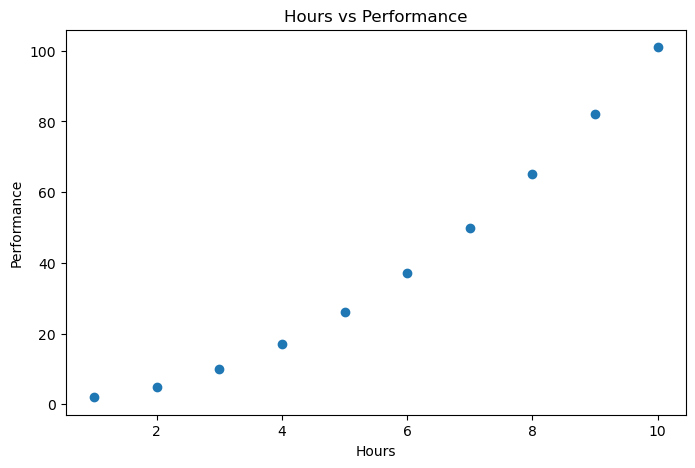

In [163]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["Hours"],
    df["Performance"])
plt.xlabel("Hours")
plt.ylabel("Performance")
plt.title("Hours vs Performance")
plt.show()

In [165]:
X = df[["Hours"]]
y = df["Performance"]

In [167]:
linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)

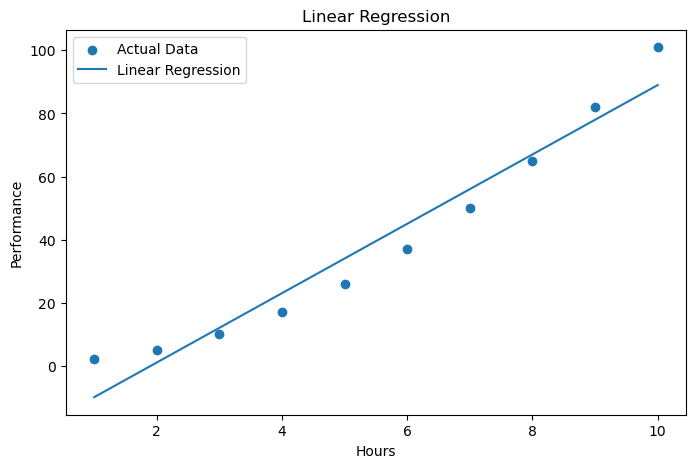

In [169]:
plt.figure(figsize=(8,5))
plt.scatter(
    X,
    y,
    label="Actual Data"
)
plt.plot(
    X,
    y_pred_linear,
    label="Linear Regression"
)
plt.xlabel("Hours")
plt.ylabel("Performance")
plt.title("Linear Regression")
plt.legend()
plt.show()

In [173]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
X_poly=poly.fit_transform(X)
print(X_poly)

[[  1.   1.   1.]
 [  1.   2.   4.]
 [  1.   3.   9.]
 [  1.   4.  16.]
 [  1.   5.  25.]
 [  1.   6.  36.]
 [  1.   7.  49.]
 [  1.   8.  64.]
 [  1.   9.  81.]
 [  1.  10. 100.]]


In [175]:
poly_model=LinearRegression()
poly_model.fit(X_poly,y)
y_pred_poly=poly_model.predict(X_poly)
print(y_pred_poly)

[  2.   5.  10.  17.  26.  37.  50.  65.  82. 101.]


In [177]:
print("Intercept:", poly_model.intercept_)
print("Coefficients:", poly_model.coef_)

Intercept: 1.0
Coefficients: [0.00000000e+00 1.83398971e-15 1.00000000e+00]


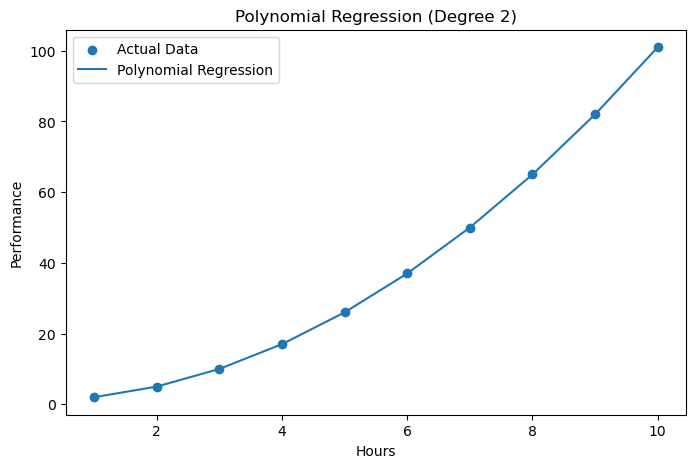

In [179]:
plt.figure(figsize=(8,5))

plt.scatter(
    X,
    y,
    label="Actual Data"
)

plt.plot(
    X,
    y_pred_poly,
    label="Polynomial Regression"
)

plt.xlabel("Hours")
plt.ylabel("Performance")
plt.title("Polynomial Regression (Degree 2)")
plt.legend()

plt.show()

In [181]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y, y_pred_poly)

mse = mean_squared_error(y, y_pred_poly)

rmse = mse ** 0.5

r2 = r2_score(y, y_pred_poly)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 3.641531520770513e-15
MSE : 3.005560048892055e-29
RMSE: 5.4822988325081795e-15
R²  : 1.0
